# Spott 本地代码与产品计划完成度分析（2026-07-18）

## TL;DR

本 Notebook 从仓库内审计矩阵重新计算完成度。中心估计：产品文档功能覆盖约 **70%**，开发计划按 Definition of Done 证据闭环约 **58%**，生产上线准备约 **26%**。这些数字是决策指标，不是对文件数或代码行数的简单计数。

## Context & Methods

审计分母为产品文档 C–T 的 18 个领域，总权重 120。每个领域按四条独立证据轴打分：

- 实现覆盖：需求是否有真实、连通的本地主线代码。
- 自动验证：当前 HEAD 是否有测试、契约和质量门证据。
- 跨端验收：iOS、Web、API/Ops 是否形成用户旅程并有当前验收证据。
- 生产就绪：真实外部服务、基础设施、SLO、合规和发布门是否完成。

产品功能覆盖 = 70% × 实现覆盖 + 30% × 跨端验收。

开发计划闭环 = 25% × 实现覆盖 + 30% × 自动验证 + 25% × 跨端验收 + 20% × 生产就绪。

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, "/tmp/spott-audit-py.d0EVuF")

import pandas as pd
import numpy as np

repo = Path.cwd()
csv_path = repo / "docs/quality/local-completion-audit-20260718.csv"
df = pd.read_csv(csv_path)

assert len(df) == 18
assert int(df["weight"].sum()) == 120
assert df[[
    "implementation_score",
    "automated_verification_score",
    "cross_platform_acceptance_score",
    "production_readiness_score",
]].apply(lambda col: col.between(0, 100).all()).all()

df[["domain", "weight", "status"]].head()

,domain,weight,status
0,C 账号与身份,8,部分闭环
1,D 发现搜索收藏,8,主流程成型
2,E 活动发布,10,主流程成型
3,F 报名候补签到,12,代码强，当前验收红
4,G 群组与关系,8,主流程成型


## Data

评分表来自 `docs/quality/local-completion-audit-20260718.csv`。它记录每个领域的权重、四轴得分、主要证据与剩余事项。权重优先倾向报名履约、活动发布、积分正确性、安全和发布验收。

In [2]:
def weighted_average(column: str) -> float:
    return float(np.average(df[column], weights=df["weight"]))

axis_scores = {
    "implementation": weighted_average("implementation_score"),
    "automated_verification": weighted_average("automated_verification_score"),
    "cross_platform_acceptance": weighted_average("cross_platform_acceptance_score"),
    "production_readiness": weighted_average("production_readiness_score"),
}

product_coverage = (
    0.70 * axis_scores["implementation"]
    + 0.30 * axis_scores["cross_platform_acceptance"]
)
development_closure = (
    0.25 * axis_scores["implementation"]
    + 0.30 * axis_scores["automated_verification"]
    + 0.25 * axis_scores["cross_platform_acceptance"]
    + 0.20 * axis_scores["production_readiness"]
)

summary = pd.DataFrame(
    [
        ["产品文档功能覆盖", product_coverage],
        ["开发计划 DoD 闭环", development_closure],
        ["生产上线准备", axis_scores["production_readiness"]],
        ["实现覆盖", axis_scores["implementation"]],
        ["自动验证", axis_scores["automated_verification"]],
        ["跨端验收", axis_scores["cross_platform_acceptance"]],
    ],
    columns=["metric", "score"],
)
summary["score"] = summary["score"].round(1)
summary

,metric,score
0,产品文档功能覆盖,69.8
1,开发计划 DoD 闭环,58.3
2,生产上线准备,26.3
3,实现覆盖,75.4
4,自动验证,66.4
5,跨端验收,56.9


## Results

下面的图把“代码功能覆盖”“开发计划证据闭环”和“生产就绪”放在同一尺度中。排序按开发计划闭环从低到高，便于优先处理最弱的领域。

Matplotlib is building the font cache; this may take a moment.


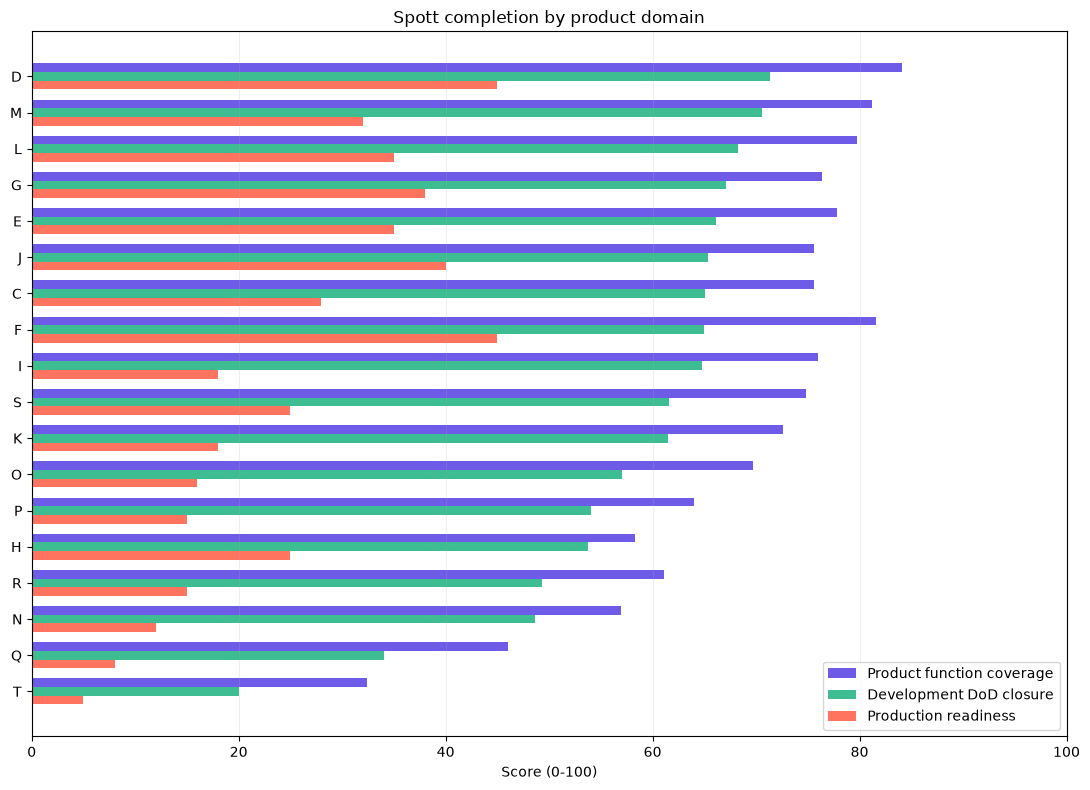

In [3]:
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["code"] = plot_df["domain"].str.split().str[0]
plot_df = plot_df.sort_values("development_plan_closure_score")

fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(plot_df))
height = 0.24
ax.barh(y + height, plot_df["functional_coverage_score"], height, label="Product function coverage", color="#6E5BE7")
ax.barh(y, plot_df["development_plan_closure_score"], height, label="Development DoD closure", color="#3DBD91")
ax.barh(y - height, plot_df["production_readiness_score"], height, label="Production readiness", color="#FF745F")
ax.set_yticks(y, plot_df["code"])
ax.set_xlim(0, 100)
ax.set_xlabel("Score (0-100)")
ax.set_title("Spott completion by product domain")
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [4]:
ranked = df[[
    "domain",
    "weight",
    "functional_coverage_score",
    "development_plan_closure_score",
    "production_readiness_score",
    "status",
]].sort_values("development_plan_closure_score", ascending=False)
ranked

,domain,weight,functional_coverage_score,development_plan_closure_score,production_readiness_score,status
1,D 发现搜索收藏,8,84.1,71.3,45,主流程成型
10,M 安全举报与审核,7,81.2,70.6,32,代码较强
9,L 分享与归因,4,79.8,68.3,35,主流程成型
4,G 群组与关系,8,76.4,67.1,38,主流程成型
2,E 活动发布,10,77.8,66.1,35,主流程成型
7,J 费用边界,4,75.6,65.4,40,产品边界成型
0,C 账号与身份,8,75.6,65.1,28,部分闭环
3,F 报名候补签到,12,81.6,65.0,45,代码强，当前验收红
6,I 积分与 StoreKit,9,76.0,64.8,18,代码成型，外部未验
16,S 配置与灰度,3,74.8,61.6,25,主流程成型


## Sensitivity

为避免假精确，使用不同权重重新计算：产品口径从更重跨端验收到更重代码实现；开发口径从四轴等权到偏重实现。结果区间用于表达评分判断的不确定性，而不是统计置信区间。

In [5]:
sensitivity = pd.DataFrame([
    {
        "scenario": "产品严格（实现60%/跨端40%）",
        "score": 0.60 * axis_scores["implementation"] + 0.40 * axis_scores["cross_platform_acceptance"],
    },
    {
        "scenario": "产品中心（实现70%/跨端30%）",
        "score": product_coverage,
    },
    {
        "scenario": "产品代码偏重（实现80%/跨端20%）",
        "score": 0.80 * axis_scores["implementation"] + 0.20 * axis_scores["cross_platform_acceptance"],
    },
    {
        "scenario": "开发严格（四轴等权）",
        "score": np.mean(list(axis_scores.values())),
    },
    {
        "scenario": "开发中心（25/30/25/20）",
        "score": development_closure,
    },
    {
        "scenario": "开发代码偏重（35/30/20/15）",
        "score": (
            0.35 * axis_scores["implementation"]
            + 0.30 * axis_scores["automated_verification"]
            + 0.20 * axis_scores["cross_platform_acceptance"]
            + 0.15 * axis_scores["production_readiness"]
        ),
    },
])
sensitivity["score"] = sensitivity["score"].round(1)
sensitivity

,scenario,score
0,产品严格（实现60%/跨端40%）,68.0
1,产品中心（实现70%/跨端30%）,69.8
2,产品代码偏重（实现80%/跨端20%）,71.7
3,开发严格（四轴等权）,56.3
4,开发中心（25/30/25/20）,58.3
5,开发代码偏重（35/30/20/15）,61.6


## Takeaways

1. 最强领域是发现、报名履约、安全与积分领域的代码深度；它们已明显超过原型阶段。
2. 当前主要短板不是“页面数量”，而是当前测试门失真、跨端连续验收和生产外部前置。
3. 产品功能覆盖的合理区间约为 68%–72%；开发计划闭环的合理区间约为 56%–62%。
4. `docs/superpowers/plans` 的复选框原始完成率只有约 22%，但它混合了过期、未回填和被总纲取代的计划，不能替代本评分。
5. 下一步应先修复测试时钟/fixture 与 CI 漏跑，再完成 Web 会话安全、Ops MFA、SwiftData 可恢复启动和十条 P0 跨端验收。